In [1]:
import pandas as pd
print("Setup done!")

Setup done!


In [2]:
dim_customers = pd.read_csv('data_files/C8_Input_Files/dim_customers.csv')
fact_spends = pd.read_csv('data_files/C8_Input_Files/fact_spends.csv')
print("dim_customers columns:", dim_customers.columns.tolist())
print("fact_spends columns:", fact_spends.columns.tolist())

dim_customers columns: ['customer_id', 'age_group', 'city', 'occupation', 'gender', 'marital status', 'avg_income']
fact_spends columns: ['customer_id', 'month', 'category', 'payment_type', 'spend']


In [3]:
dim_customers


,customer_id,age_group,city,occupation,gender,marital status,avg_income
0,ATQCUS1825,45+,Bengaluru,Salaried IT Employees,Male,Married,73523
1,ATQCUS0809,25-34,Hyderabad,Salaried Other Employees,Male,Married,39922
2,ATQCUS0663,25-34,Chennai,Salaried Other Employees,Male,Married,37702
3,ATQCUS0452,25-34,Delhi NCR,Government Employees,Male,Married,54090
4,ATQCUS3350,21-24,Bengaluru,Freelancers,Male,Single,28376
...,...,...,...,...,...,...,...
3995,ATQCUS3035,45+,Delhi NCR,Business Owners,Female,Married,72805
3996,ATQCUS2585,35-45,Mumbai,Salaried Other Employees,Female,Married,41343
3997,ATQCUS1229,35-45,Bengaluru,Salaried IT Employees,Male,Married,65948
3998,ATQCUS0581,25-34,Bengaluru,Government Employees,Male,Married,52589


In [4]:
print("City values:", dim_customers['city'].unique())

City values: <StringArray>
['Bengaluru', 'Hyderabad', 'Chennai', 'Delhi NCR', 'Mumbai']
Length: 5, dtype: str


In [5]:
print("age_group:", dim_customers['age_group'].unique())
print("occupation:", dim_customers['occupation'].unique())
print("gender:", dim_customers['gender'].unique())
print("marital status:", dim_customers['marital status'].unique())
print()
print("month:", fact_spends['month'].unique())
print("category:", fact_spends['category'].unique())
print("payment_type:", fact_spends['payment_type'].unique())

age_group: <StringArray>
['45+', '25-34', '21-24', '35-45']
Length: 4, dtype: str
occupation: <StringArray>
[   'Salaried IT Employees', 'Salaried Other Employees',
     'Government Employees',              'Freelancers',
          'Business Owners']
Length: 5, dtype: str
gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
marital status: <StringArray>
['Married', 'Single']
Length: 2, dtype: str

month: <StringArray>
['July', 'October', 'May', 'September', 'June', 'August']
Length: 6, dtype: str
category: <StringArray>
['Health & Wellness',         'Groceries',       'Electronics',
             'Bills',     'Entertainment',           'Apparel',
              'Food',            'Others',            'Travel']
Length: 9, dtype: str
payment_type: <StringArray>
['Credit Card', 'UPI', 'Debit Card', 'Net Banking']
Length: 4, dtype: str


In [6]:
print("Nulls in dim_customers:\n", dim_customers.isnull().sum())
print("\nNulls in fact_spends:\n", fact_spends.isnull().sum())
print("\nDuplicate customer_ids:", dim_customers['customer_id'].duplicated().sum())
print("Duplicate rows in fact_spends:", fact_spends.duplicated().sum())

Nulls in dim_customers:
 customer_id       0
age_group         0
city              0
occupation        0
gender            0
marital status    0
avg_income        0
dtype: int64

Nulls in fact_spends:
 customer_id     0
month           0
category        0
payment_type    0
spend           0
dtype: int64

Duplicate customer_ids: 0
Duplicate rows in fact_spends: 0


In [7]:
# Standardize column names
dim_customers = dim_customers.rename(columns={'marital status': 'marital_status'})

# Standardize city value
dim_customers['city'] = dim_customers['city'].replace({'Delhi NCR': 'Delhi-NCR'})

print("Updated columns:", dim_customers.columns.tolist())
print("Updated city values:", dim_customers['city'].unique())

Updated columns: ['customer_id', 'age_group', 'city', 'occupation', 'gender', 'marital_status', 'avg_income']
Updated city values: <StringArray>
['Bengaluru', 'Hyderabad', 'Chennai', 'Delhi-NCR', 'Mumbai']
Length: 5, dtype: str


In [8]:
# Step 1: Har customer ka total spend, har month mein (sab categories/payment types add karke)
monthly_spend = fact_spends.groupby(['customer_id', 'month'])['spend'].sum().reset_index()

print(monthly_spend.head(10))

  customer_id      month  spend
0  ATQCUS0001     August  33776
1  ATQCUS0001       July  29451
2  ATQCUS0001       June  26316
3  ATQCUS0001        May  19480
4  ATQCUS0001    October  25262
5  ATQCUS0001  September  36260
6  ATQCUS0002     August  29343
7  ATQCUS0002       July  27237
8  ATQCUS0002       June  22721
9  ATQCUS0002        May  19501


In [9]:
# Step 2: Har customer ka average monthly spend (6 months ka average)
avg_monthly_spend = monthly_spend.groupby('customer_id')['spend'].mean().reset_index()
avg_monthly_spend = avg_monthly_spend.rename(columns={'spend': 'avg_monthly_spend'})

print(avg_monthly_spend.head(10))

  customer_id  avg_monthly_spend
0  ATQCUS0001       28424.166667
1  ATQCUS0002       28085.666667
2  ATQCUS0003       26255.666667
3  ATQCUS0004       27109.166667
4  ATQCUS0005       26216.000000
5  ATQCUS0006       30855.333333
6  ATQCUS0007       26474.000000
7  ATQCUS0008       26162.166667
8  ATQCUS0009       29624.666667
9  ATQCUS0010       29957.666667


In [10]:
# Step 3: Customer demographics ko avg_monthly_spend ke saath jodo
cust = dim_customers.merge(avg_monthly_spend, on='customer_id', how='left')

print(cust.head())
print("\nShape:", cust.shape)

  customer_id age_group       city                occupation gender  \
0  ATQCUS1825       45+  Bengaluru     Salaried IT Employees   Male   
1  ATQCUS0809     25-34  Hyderabad  Salaried Other Employees   Male   
2  ATQCUS0663     25-34    Chennai  Salaried Other Employees   Male   
3  ATQCUS0452     25-34  Delhi-NCR      Government Employees   Male   
4  ATQCUS3350     21-24  Bengaluru               Freelancers   Male   

  marital_status  avg_income  avg_monthly_spend  
0        Married       73523       32400.666667  
1        Married       39922       16518.666667  
2        Married       37702       11517.000000  
3        Married       54090       20384.833333  
4         Single       28376       12251.000000  

Shape: (4000, 8)


In [11]:
# Step 4: Income Utilisation % = avg monthly spend / avg income * 100
cust['income_util_pct'] = (cust['avg_monthly_spend'] / cust['avg_income']) * 100

print(cust[['customer_id', 'avg_income', 'avg_monthly_spend', 'income_util_pct']].head(10))
print("\nOverall average income utilisation %:", cust['income_util_pct'].mean())

  customer_id  avg_income  avg_monthly_spend  income_util_pct
0  ATQCUS1825       73523       32400.666667        44.068749
1  ATQCUS0809       39922       16518.666667        41.377353
2  ATQCUS0663       37702       11517.000000        30.547451
3  ATQCUS0452       54090       20384.833333        37.686880
4  ATQCUS3350       28376       12251.000000        43.173809
5  ATQCUS3256       46586       27711.666667        59.484967
6  ATQCUS3608       34966       11349.000000        32.457244
7  ATQCUS0611       59078       22498.666667        38.082986
8  ATQCUS3856       30424       11590.000000        38.094925
9  ATQCUS2640       67450       32626.333333        48.371139

Overall average income utilisation %: 42.948018088570855


In [12]:
cust.to_csv('cust_master.csv', index=False)
print("Saved!")

Saved!


In [13]:
occupation_summary = cust.groupby('occupation').agg(
    customers=('customer_id', 'count'),
    avg_income=('avg_income', 'mean'),
    avg_monthly_spend=('avg_monthly_spend', 'mean'),
    avg_util_pct=('income_util_pct', 'mean')
).round(1).sort_values('avg_util_pct', ascending=False)

print(occupation_summary)

                          customers  avg_income  avg_monthly_spend  \
occupation                                                           
Salaried IT Employees          1294     61499.7            31391.1   
Freelancers                     784     35058.3            16058.4   
Salaried Other Employees        893     38793.4            16332.9   
Business Owners                 630     70091.2            23281.7   
Government Employees            399     52034.8            15088.7   

                          avg_util_pct  
occupation                              
Salaried IT Employees             50.9  
Freelancers                       45.7  
Salaried Other Employees          42.0  
Business Owners                   33.2  
Government Employees              29.0  


**Key Insight:** Business Owners have the highest average income (₹70,091) — the wealthiest segment in the sample — yet they show one of the lowest income utilisation rates (33.2%). This suggests they earn significantly more than they spend relative to their income, possibly channeling surplus into savings/investments, or tracking business-related expenses separately from personal spend.

In contrast, Salaried IT Employees earn somewhat less (₹61,500 average) but spend the highest share of their income (50.9% utilisation) — a combination of decent income and high spending activity that makes them the most promising segment for the new credit card, as it signals both affordability and active day-to-day usage.

In [14]:
city_summary = cust.groupby('city').agg(
    customers=('customer_id', 'count'),
    avg_income=('avg_income', 'mean'),
    avg_monthly_spend=('avg_monthly_spend', 'mean'),
    avg_util_pct=('income_util_pct', 'mean')
).round(1).sort_values('avg_util_pct', ascending=False)

print(city_summary)

           customers  avg_income  avg_monthly_spend  avg_util_pct
city                                                             
Mumbai          1078     51720.3            26598.4          51.6
Delhi-NCR        744     51982.7            24966.3          48.1
Bengaluru        751     51073.3            22196.6          43.7
Hyderabad        593     52344.8            18977.0          36.5
Chennai          834     51321.4            15961.5          31.1


**Key Insight** Average income is nearly uniform across all five cities (₹51,000–52,000), yet income utilisation varies significantly — from 31.1% in Chennai to 51.6% in Mumbai. This indicates the difference in card-readiness across cities is driven by spending behaviour and lifestyle, not income levels. Mumbai and Delhi-NCR customers spend a considerably larger share of their income, making them the strongest geographic markets for the credit card launch."

In [15]:
age_summary = cust.groupby('age_group').agg(
    customers=('customer_id', 'count'),
    avg_income=('avg_income', 'mean'),
    avg_monthly_spend=('avg_monthly_spend', 'mean'),
    avg_util_pct=('income_util_pct', 'mean')
).round(1).reindex(['21-24', '25-34', '35-45', '45+']).sort_values('avg_util_pct', ascending=False)

print(age_summary)

           customers  avg_income  avg_monthly_spend  avg_util_pct
age_group                                                        
35-45           1273     53426.0            24959.4          46.6
25-34           1498     51827.1            22625.4          43.8
21-24            691     40718.3            16527.5          40.5
45+              538     61047.6            21182.7          35.1


**Key Insight:** The 45+ age group has the highest average income (₹61,048) of any age segment, yet shows the lowest income utilisation (35.1%) — mirroring the pattern seen with Business Owners. In contrast, the 35-45 and 25-34 groups combine solid income with the highest utilisation (46.6% and 43.8% respectively), making the 25-45 age band the strongest overall target range.

This is the third instance (after occupation and city) where higher income does not translate to higher spending share — reinforcing that income alone is a poor predictor of credit card readiness, and utilisation is the more reliable signal to design around

In [16]:
gender_summary = cust.groupby('gender').agg(
    customers=('customer_id', 'count'),
    avg_income=('avg_income', 'mean'),
    avg_util_pct=('income_util_pct', 'mean')
).round(1)

marital_summary = cust.groupby('marital_status').agg(
    customers=('customer_id', 'count'),
    avg_income=('avg_income', 'mean'),
    avg_util_pct=('income_util_pct', 'mean')
).round(1)

print("Gender:\n", gender_summary)
print("\nMarital Status:\n", marital_summary)

Gender:
         customers  avg_income  avg_util_pct
gender                                     
Female       1403     51700.7          39.6
Male         2597     51633.4          44.7

Marital Status:
                 customers  avg_income  avg_util_pct
marital_status                                     
Married              3136     53316.5          43.0
Single                864     45633.7          42.8


**Gender & Marital Status:** Average income is nearly identical between male and female customers (~₹51,650), yet male customers show meaningfully higher income utilisation (44.7% vs 39.6% for females) — a behavioural difference not explained by income level. Marital status shows the opposite pattern: married customers earn more (₹53,317 vs ₹45,634 for single customers), but utilisation is nearly identical across both groups (43.0% vs 42.8%), suggesting marital status has limited influence on spending behaviour in this dataset.

In [17]:
df = fact_spends.merge(dim_customers, on='customer_id', how='left')
print(df.shape)
print(df.head())

(864000, 11)
  customer_id      month           category payment_type  spend age_group  \
0  ATQCUS1371       July  Health & Wellness  Credit Card   1114     35-45   
1  ATQCUS0368    October          Groceries  Credit Card   1466     25-34   
2  ATQCUS0595        May  Health & Wellness  Credit Card    387     25-34   
3  ATQCUS0667    October        Electronics  Credit Card   1137     25-34   
4  ATQCUS3477  September              Bills          UPI   2102     25-34   

        city                occupation gender marital_status  avg_income  
0    Chennai     Salaried IT Employees   Male        Married       64696  
1  Delhi-NCR  Salaried Other Employees   Male        Married       39893  
2  Bengaluru      Government Employees   Male        Married       52001  
3    Chennai  Salaried Other Employees   Male        Married       40243  
4     Mumbai           Business Owners   Male         Single       73541  


In [18]:
category_summary = df.groupby('category')['spend'].sum().sort_values(ascending=False)
category_pct = (category_summary / category_summary.sum() * 100).round(1)

print("Total spend by category:\n", category_summary)
print("\n% share of total spend:\n", category_pct)

Total spend by category:
 category
Bills                104912768
Groceries             86303761
Electronics           79562220
Health & Wellness     65599867
Travel                59223324
Food                  44013470
Entertainment         41289162
Apparel               34036001
Others                15957182
Name: spend, dtype: int64

% share of total spend:
 category
Bills                19.8
Groceries            16.3
Electronics          15.0
Health & Wellness    12.4
Travel               11.2
Food                  8.3
Entertainment         7.8
Apparel               6.4
Others                3.0
Name: spend, dtype: float64


**Spending Pattern:** Bills (19.8%), Groceries (16.3%), and Electronics (15.0%) together account for roughly half of all customer spending — indicating essential/recurring expenses dominate over discretionary categories like Entertainment (7.8%) and Apparel (6.4%). A credit card designed around cashback on Bills, Groceries, and Electronics would align with where customers already spend the most.


In [19]:
cat_by_age = df.groupby(['age_group', 'category'])['spend'].sum().reset_index()
top_cat_per_age = cat_by_age.loc[cat_by_age.groupby('age_group')['spend'].idxmax()]

print(top_cat_per_age[['age_group', 'category', 'spend']])

   age_group       category     spend
3      21-24  Entertainment  15122236
10     25-34          Bills  43955835
19     35-45          Bills  42077837
28       45+          Bills  15365396


**Key Insight:** Every age group's top spending category is Bills — except the 21-24 age group, whose highest spend category is Entertainment. This is a clear behavioural signal that younger customers prioritise lifestyle/discretionary spending over recurring essentials, unlike every older segment. This strongly supports designing a distinct "youth" card variant with entertainment-focused rewards, rather than a one-size-fits-all bills-cashback card.

In [20]:
payment_summary = df.groupby('payment_type')['spend'].sum().sort_values(ascending=False)
payment_pct = (payment_summary / payment_summary.sum() * 100).round(1)

print(payment_pct)

payment_type
Credit Card    40.7
UPI            26.5
Debit Card     22.5
Net Banking    10.2
Name: spend, dtype: float64


**Payment Behaviour:** Credit Card is already the leading payment method by value, accounting for 40.7% of total spend — ahead of UPI (26.5%) and Debit Card (22.5%). This indicates strong existing comfort with credit card usage among this customer base, validating that a new credit card product should find a receptive market rather than needing to shift entrenched payment habits.

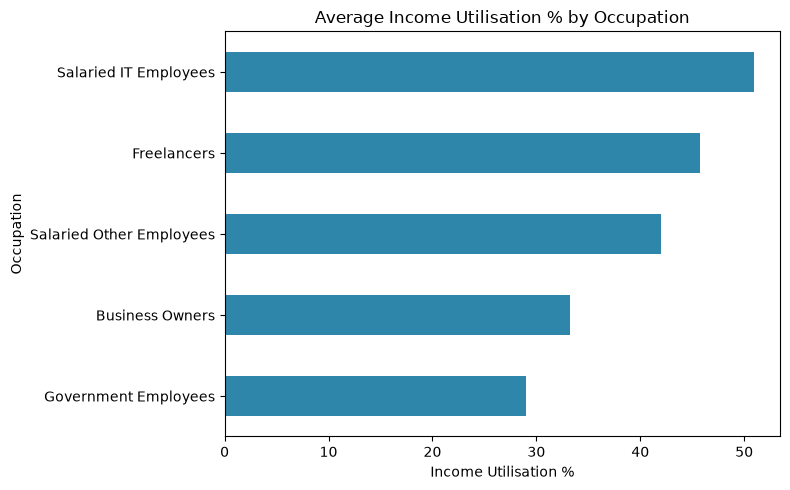

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
occupation_summary['avg_util_pct'].sort_values().plot(kind='barh', color='#2E86AB')
plt.title('Average Income Utilisation % by Occupation')
plt.xlabel('Income Utilisation %')
plt.ylabel('Occupation')
plt.tight_layout()
plt.show()

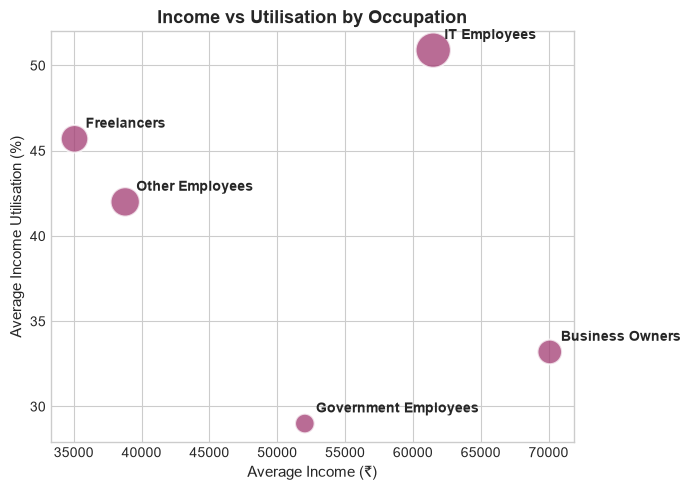

In [25]:
plt.style.use('seaborn-v0_8-whitegrid')  # cleaner look

plt.figure(figsize=(7,5))
plt.scatter(occupation_summary['avg_income'], occupation_summary['avg_util_pct'], 
            s=occupation_summary['customers']/2, color='#A23B72', alpha=0.75, edgecolors='white', linewidth=1.5)

for occ in occupation_summary.index:
    plt.annotate(occ.replace('Salaried ',''), 
                 (occupation_summary.loc[occ,'avg_income'], occupation_summary.loc[occ,'avg_util_pct']),
                 xytext=(8,8), textcoords='offset points', fontsize=10, fontweight='bold')

plt.xlabel('Average Income (₹)', fontsize=11)
plt.ylabel('Average Income Utilisation (%)', fontsize=11)
plt.title('Income vs Utilisation by Occupation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

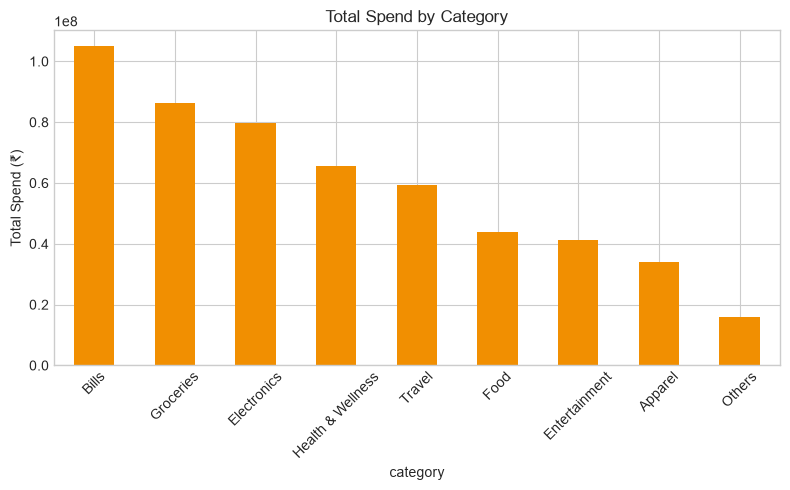

In [26]:
plt.figure(figsize=(8,5))
category_summary.plot(kind='bar', color='#F18F01')
plt.title('Total Spend by Category')
plt.ylabel('Total Spend (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

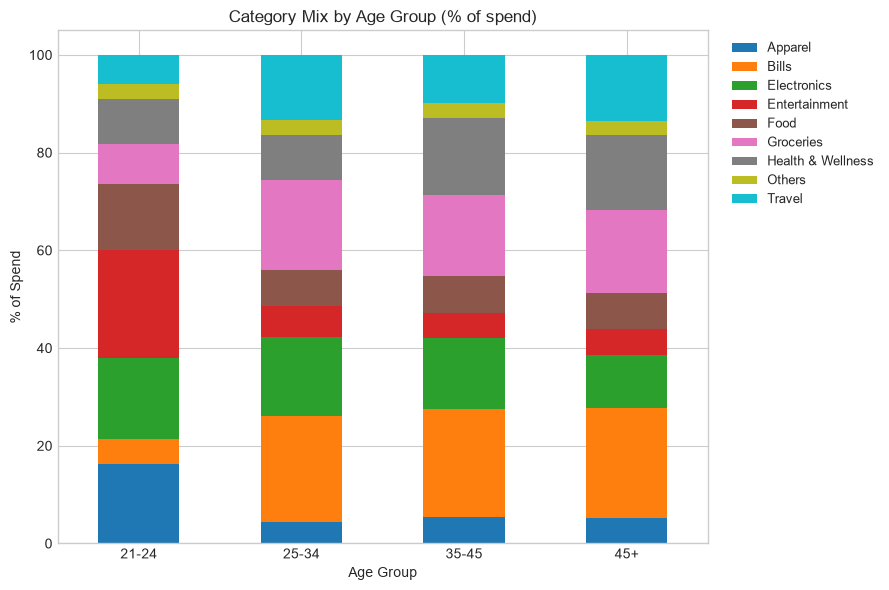

In [27]:
cat_age_pct = df.groupby(['age_group','category'])['spend'].sum().unstack()
cat_age_pct = cat_age_pct.div(cat_age_pct.sum(axis=1), axis=0) * 100
cat_age_pct = cat_age_pct.reindex(['21-24','25-34','35-45','45+'])

cat_age_pct.plot(kind='bar', stacked=True, figsize=(9,6), colormap='tab10')
plt.title('Category Mix by Age Group (% of spend)')
plt.ylabel('% of Spend')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [28]:
df.to_csv('fact_merged.csv', index=False)
print("Saved fact_merged.csv, shape:", df.shape)

cust.to_csv('cust_master.csv', index=False)
print("Saved cust_master.csv, shape:", cust.shape)

Saved fact_merged.csv, shape: (864000, 11)
Saved cust_master.csv, shape: (4000, 9)
